
SNIPPET-LEVEL METRICS (Frame-by-Frame):
ROC-AUC = 0.7451
Average Precision (AP) = 0.4618


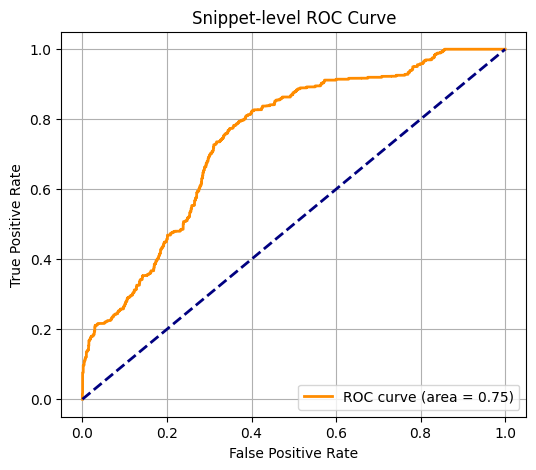

In [6]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from scipy.interpolate import interp1d
import pandas as pd

from model import WSAD
from dataset_loader import FeatureDataset

# ======================================================================
# Inference Function
# ======================================================================
def run_inference(model, test_loader, snippet_frame_count=16):
    model.eval()
    model.flag = "Test"

    video_max_scores = []
    video_labels = []
    snippet_scores_dict = {}
    all_frame_predictions = []

    with torch.no_grad():
        for data, label, name in test_loader:
            label = int(label.item())
            name = name[0] if isinstance(name, (list, tuple)) else str(name)
            data = data.cuda()

            out = model(data)
            # Get snippet-level scores (usually shape [200])
            snippet_scores = out["frame"].squeeze().cpu().numpy()

            snippet_scores_dict[name] = snippet_scores
            video_max_scores.append(snippet_scores.max())
            video_labels.append(label)

            # Expand snippet scores to frames (16 frames per snippet)
            fpre_expanded = np.repeat(snippet_scores, snippet_frame_count)
            all_frame_predictions.extend(fpre_expanded)

    return video_max_scores, video_labels, snippet_scores_dict, np.array(all_frame_predictions)

# ======================================================================
# Metrics + Plots
# ======================================================================
def evaluate_snippet_level(frame_predict, gt_path="frame_label/frame_gt.npy"):
    # Load the frame-level ground truth
    frame_gt = np.load(gt_path)
    
    # Interpolate predictions to match frame_gt length exactly
    if len(frame_predict) != len(frame_gt):
        x_old = np.linspace(0, 1, num=len(frame_predict))
        x_new = np.linspace(0, 1, num=len(frame_gt))
        f = interp1d(x_old, frame_predict, kind="linear")
        frame_predict = f(x_new)

    # Calculate Snippet-level (Frame) AUC
    fpr, tpr, _ = roc_curve(frame_gt, frame_predict)
    snippet_auc = auc(fpr, tpr)

    # Calculate Snippet-level Average Precision (AP)
    precision, recall, _ = precision_recall_curve(frame_gt, frame_predict)
    snippet_ap = auc(recall, precision)

    print(f"\nSNIPPET-LEVEL METRICS (Frame-by-Frame):")
    print(f"ROC-AUC = {snippet_auc:.4f}")
    print(f"Average Precision (AP) = {snippet_ap:.4f}")

    return snippet_auc, snippet_ap, fpr, tpr

# ======================================================================
# MAIN
# ======================================================================
if __name__ == "__main__":
    # 1. Load model
    model = WSAD(input_size=1024, flag="Test", a_nums=60, n_nums=60).cuda()
    model_path = "models/versions/moerdijk_model_newencoder_v2.pkl"
    model.load_state_dict(torch.load(model_path, map_location="cuda"))

    # 2. Load test dataset
    test_loader = DataLoader(
        FeatureDataset(root_dir=".", modal="RGB", mode="Test", num_segments=200, len_feature=1024),
        batch_size=1, shuffle=False, num_workers=2
    )

    # 3. Run Inference
    # We now collect 'frame_predictions' which is the long list of all expanded scores
    v_max_scores, v_labels, snippet_dict, frame_predictions = run_inference(model, test_loader)

    # 4. Snippet-Level Evaluation (Using frame_gt.npy)
    snippet_auc, snippet_ap, fpr, tpr = evaluate_snippet_level(frame_predictions)

    # 5. Visualization
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {snippet_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Snippet-level ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # 6. Save Data
    rows = []
    for (name, snippet_scores), v_score, v_label in zip(snippet_dict.items(), v_max_scores, v_labels):
        rows.append({
            "Video Name": name,
            "Video Label": v_label,
            "Max Anomaly Score": v_score,
            "Avg Anomaly Score": snippet_scores.mean()
        })
    df = pd.DataFrame(rows)
    

### Plot costs for training

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

def plot_training_cost(csv_path, show=True, save_path=None):
    """
    Load training cost CSV and plot it.
    
    Args:
        csv_path (str): Path to the CSV file.
        show (bool): Whether to show the plot immediately.
        save_path (str or None): If given, save the plot to this path.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    # Load CSV
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)  # skip header if present

    # Handle two cases: CSV with steps or just values
    if data.ndim == 1 or data.shape[1] == 1:
        steps = np.arange(1, len(data) + 1)
        costs = data.flatten()
    else:
        steps = data[:, 0]
        costs = data[:, 1]

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(steps, costs, label="Training Cost")
    plt.xlabel("Step")
    plt.ylabel("Cost")
    plt.title("Training Cost over Steps")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    if show:
        plt.show()


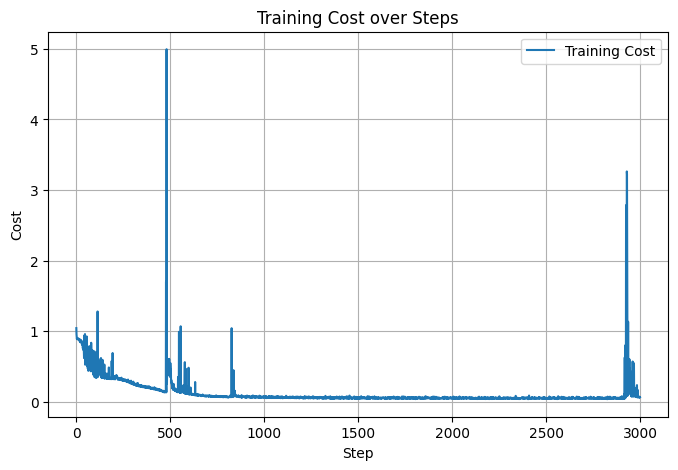

In [ ]:
csv_path = "outputs/loss/train_costs_v2.csv"
plot_training_cost(csv_path)

### Visualize anomalies in video

In [1]:
import os
import random
import re
import cv2
import torch
import numpy as np
from torch.utils.data import DataLoader
from model import WSAD
from dataset_loader import FeatureDataset

##helpers
def feature_name_to_video_name(feature_name):
    # remove _i3d.npy and add .mp4
    return feature_name.replace("_i3d.npy", "") + ".mp4"


# ============================================================
# Inference
# ============================================================
def run_inference(model, test_loader, snippet_frame_count=16):
    model.eval()
    model.flag = "Test"

    snippet_scores_dict = {}

    with torch.no_grad():
        for data, label, name in test_loader:
            name = name[0] if isinstance(name, (list, tuple)) else str(name)
            data = data.cuda()

            out = model(data)
            snippet_scores = out["frame"].squeeze().cpu().numpy()
            snippet_scores_dict[name] = snippet_scores

    return snippet_scores_dict


# ============================================================
# Play video with live anomaly scores
# ============================================================
def play_video_file_with_anomaly_scores(video_path, snippet_scores, snippet_frame_count=16, window_name="Video with Anomaly Scores"):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Video not found or cannot be opened: {video_path}")

    # Compute per-frame scores
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_scores = np.repeat(snippet_scores, snippet_frame_count)
    frame_scores = frame_scores[:total_frames]

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Get current anomaly score
        score = frame_scores[idx] if idx < len(frame_scores) else 0.0

        # Draw score as text
        text = f"Anomaly score: {score:.2f}"
        cv2.putText(frame, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 0, 255), 2)

        # Draw score bar on the right side
        bar_height = int(score * frame.shape[0])
        cv2.rectangle(frame, (frame.shape[1]-50, frame.shape[0]-bar_height),
                      (frame.shape[1]-20, frame.shape[0]), (0, 0, 255), -1)

        cv2.imshow(window_name, frame)

        # Press 'q' to quit early
        if cv2.waitKey(int(1000 / cap.get(cv2.CAP_PROP_FPS))) & 0xFF == ord('q'):
            break

        idx += 1

    cap.release()
    cv2.destroyAllWindows()


# ============================================================
# MAIN
# ============================================================
if __name__ == "__main__":

    VIDEO_ROOT = "data/test"  # folder with your video files

    # ---- load model ----
    model = WSAD(input_size=1024, flag="Test", a_nums=60, n_nums=60).cuda()
    model_path = "models/versions/moerdijk_model_newencoder_v2.pkl"
    model.load_state_dict(torch.load(model_path))
    model.eval()

    # ---- load test dataset ----
    test_loader = DataLoader(
        FeatureDataset(
            root_dir=".",
            modal="RGB",
            mode="Test",
            num_segments=200,
            len_feature=1024
        ),
        batch_size=1,
        shuffle=False,
        num_workers=2
    )

    # ---- inference ----
    snippet_scores_dict = run_inference(model, test_loader)

    # ---- randomly pick one test video ----
    video_name = random.choice(list(snippet_scores_dict.keys()))
    snippet_scores = snippet_scores_dict[video_name]

    print(f"Visualizing: {video_name}")

    # ---- full video path ----
    video_file = os.path.join(VIDEO_ROOT, feature_name_to_video_name(video_name))
    if not os.path.isfile(video_file):
        raise FileNotFoundError(f"Video file not found: {video_file}")

    # ---- play video with live anomaly scores ----
    play_video_file_with_anomaly_scores(
        video_file,
        snippet_scores,
        snippet_frame_count=16
    )


Visualizing: video_eo_96_20094_norm_i3d.npy


In [8]:
snippet_scores_dict.keys()

dict_keys(['video_eo_96_500_ab_i3d.npy', 'video_eo_96_2485_ab_i3d.npy', 'video_eo_96_4100_ab_i3d.npy', 'video_eo_96_5620_ab_i3d.npy', 'video_eo_96_11025_ab_i3d.npy', 'video_eo_96_15365_ab_i3d.npy', 'video_eo_96_20945_ab_i3d.npy', 'video_eo_96_21913_ab_i3d.npy', 'video_eo_96_0_norm_i3d.npy', 'video_eo_96_1816_norm_i3d.npy', 'video_eo_96_2263_norm_i3d.npy', 'video_eo_96_3021_norm_i3d.npy', 'video_eo_96_3468_norm_i3d.npy', 'video_eo_96_3915_norm_i3d.npy', 'video_eo_96_4711_norm_i3d.npy', 'video_eo_96_5158_norm_i3d.npy', 'video_eo_96_6821_norm_i3d.npy', 'video_eo_96_7268_norm_i3d.npy', 'video_eo_96_7715_norm_i3d.npy', 'video_eo_96_8162_norm_i3d.npy', 'video_eo_96_8609_norm_i3d.npy', 'video_eo_96_9056_norm_i3d.npy', 'video_eo_96_9503_norm_i3d.npy', 'video_eo_96_9950_norm_i3d.npy', 'video_eo_96_10397_norm_i3d.npy', 'video_eo_96_10844_norm_i3d.npy', 'video_eo_96_11426_norm_i3d.npy', 'video_eo_96_11873_norm_i3d.npy', 'video_eo_96_12320_norm_i3d.npy', 'video_eo_96_12767_norm_i3d.npy', 'video_eo

In [2]:
import numpy as np

# Filter snippets with at least one score in the desired range
target_snippets = snippet_scores_dict

print(f"Found {len(target_snippets)} snippets containing scores in range [0.05, 1]:\n")

# Separate lists for 'ab' and 'norm'
ab_scores = []
norm_scores = []

for filename, scores in target_snippets.items():
    max_score = np.max(scores)
    # print(f"{filename}: Max Score = {max_score:.4f}")
    
    if 'ab' in filename.lower():
        ab_scores.append(np.mean(scores))  # Average score per video
        # print(filename.lower())
    elif 'norm' in filename.lower():
        norm_scores.append(np.mean(scores))

# Compute averages per group
avg_ab = np.mean(ab_scores) if ab_scores else float('nan')
avg_norm = np.mean(norm_scores) if norm_scores else float('nan')

print(f"\nAverage score for videos with 'ab' in the name: {avg_ab:.4f}")
print(f"Average score for videos with 'norm' in the name: {avg_norm:.4f}")


Found 59 snippets containing scores in range [0.05, 1]:


Average score for videos with 'ab' in the name: 0.0336
Average score for videos with 'norm' in the name: 0.0001


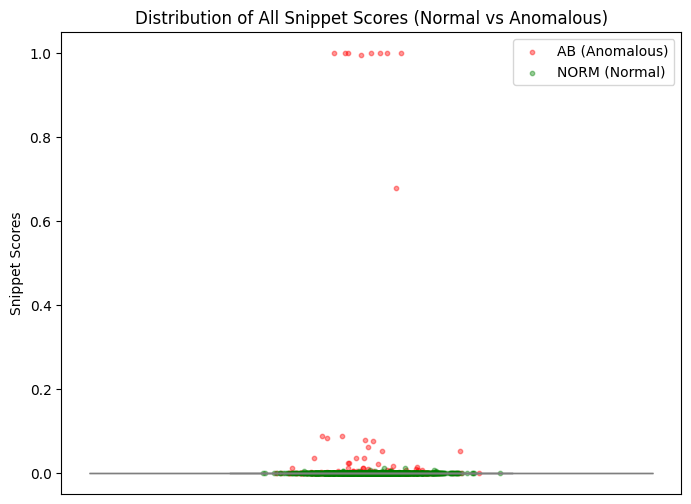

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare lists for all scores
ab_scores_all = []
norm_scores_all = []

for filename, scores in snippet_scores_dict.items():
    if 'ab' in filename.lower():
        ab_scores_all.extend(scores)
    elif 'norm' in filename.lower():
        norm_scores_all.extend(scores)

# Combine all scores for single-column plot
all_scores = ab_scores_all + norm_scores_all

# Boxplot (single column)
plt.figure(figsize=(8,6))
sns.boxplot(y=all_scores, color='lightgray', showfliers=False)

# Scatter points with jitter
y_jitter_ab = np.array(ab_scores_all)
y_jitter_norm = np.array(norm_scores_all)

x_jitter_ab = np.random.normal(loc=0, scale=0.05, size=len(ab_scores_all))
x_jitter_norm = np.random.normal(loc=0, scale=0.05, size=len(norm_scores_all))

plt.scatter(x_jitter_ab, y_jitter_ab, color='red', alpha=0.4, s=10, label='AB (Anomalous)')
plt.scatter(x_jitter_norm, y_jitter_norm, color='green', alpha=0.4, s=10, label='NORM (Normal)')

plt.xticks([])  # remove x-tick labels
plt.ylabel('Snippet Scores')
plt.title('Distribution of All Snippet Scores (Normal vs Anomalous)')
plt.legend()
plt.show()
